# Layer STG — Análisis Exploratorio de Datos (EDA) y Limpieza

**Objetivo:** Examinar el conjunto de datos crudo, aplicar un pipeline de limpieza para solucionar problemas de formato, y descubrir patrones subyacentes mediante estadísticas y gráficos cruzados.

## Contenido (Fases del EDA)
1. Carga de datos RAW
2. Análisis Exploratorio de Datos (EDA)
3. Limpieza de Datos (Pipeline scikit-learn)
4. Análisis Estadístico Descriptivo y Detección de Valores Atípicos
5. Visualización de Datos (Univariable y Bivariable)
6. Métricas de calidad
7. Guardar capa STG

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from IPython.display import display

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
sns.set_theme(style='whitegrid')

BASE_DIR = Path().resolve().parent
RAW_DIR  = BASE_DIR / "data" / "raw"
STG_DIR  = BASE_DIR / "data" / "stg"
STG_DIR.mkdir(parents=True, exist_ok=True)

print("Entorno configurado.")

Entorno configurado.


## 1. Carga de datos RAW

Los 3 archivos de recorridos tienen esquemas ligeramente distintos:
- **2022/2023**: columnas índice extra, IDs con sufijo `BAEcobici`, duración con coma.
- **2024**: formato limpio y consistente.

In [2]:
def load_raw_recorridos(year: int) -> pd.DataFrame:
    df = pd.read_parquet(RAW_DIR / f"recorridos_{year}.parquet")
    df['anio'] = year
    return df

def load_raw_usuarios(year: int) -> pd.DataFrame:
    df = pd.read_parquet(RAW_DIR / f"usuarios_{year}.parquet")
    df['anio'] = year
    return df

r2022 = load_raw_recorridos(2022)
r2023 = load_raw_recorridos(2023)
r2024 = load_raw_recorridos(2024)

u2022 = load_raw_usuarios(2022)
u2023 = load_raw_usuarios(2023)
u2024 = load_raw_usuarios(2024)

## 2. Análisis Exploratorio de Datos (EDA)
Al igual que en metodologías exhaustivas, antes de procesar la información realizaremos un análisis exploratorio preliminar sobre los datos crudos. 

**Objetivos:** 
1. Inspección inicial y estadísticas descriptivas crudas.
2. Planteo de hipótesis sobre la calidad y distribución de los datos.
3. Visualizaciones que evidencien la necesidad de limpieza.
4. Conclusiones e insights técnicos.

In [3]:
print("=== HIPÓTESIS SOBRE LA CALIDAD DE LOS DATOS CRUDOS ===")
print("H1 (Outliers): Existen valores atípicos extremos en la duración de los viajes (ej. bicicletas rotas o no devueltas) que sesgan cualquier análisis de tiempo.")
print("H2 (Inconsistencia Categórica): Las variables de texto libre, como el género, contienen múltiples formatos y valores nulos dependiendo del año de extracción.")
print("H3 (Estructura): La cantidad de datos nulos varía significativamente entre columnas, requiriendo decisiones de imputación o descarte.\n")

print("=== ESTADÍSTICAS DESCRIPTIVAS CRUDAS (Muestra 2024 y 2022) ===")
# Forzamos a numérico la duración cruda para ver la catástrofe de los outliers
duracion_cruda = pd.to_numeric(r2024['duracion_recorrido'], errors='coerce')

print("1. Resumen estadístico de 'duracion_recorrido' crudo (en segundos):")
# Evitamos notación científica para ver la magnitud real de los errores
print(duracion_cruda.describe().apply(lambda x: format(x, '.1f')))

print("\n2. Conteo de la variable Género en estado crudo (Muestra 2022):")
# Usamos try-except o buscamos la columna porque viene sucia ('Género' vs 'genero')
col_genero = 'genero' if 'genero' in r2022.columns else 'G\u00e9nero' if 'G\u00e9nero' in r2022.columns else 'Género'
if col_genero in r2022.columns:
    print(r2022[col_genero].value_counts(dropna=False).to_string())

=== HIPÓTESIS SOBRE LA CALIDAD DE LOS DATOS CRUDOS ===
H1 (Outliers): Existen valores atípicos extremos en la duración de los viajes (ej. bicicletas rotas o no devueltas) que sesgan cualquier análisis de tiempo.
H2 (Inconsistencia Categórica): Las variables de texto libre, como el género, contienen múltiples formatos y valores nulos dependiendo del año de extracción.
H3 (Estructura): La cantidad de datos nulos varía significativamente entre columnas, requiriendo decisiones de imputación o descarte.

=== ESTADÍSTICAS DESCRIPTIVAS CRUDAS (Muestra 2024 y 2022) ===
1. Resumen estadístico de 'duracion_recorrido' crudo (en segundos):
count    3559284.0
mean        1274.8
std         9584.2
min            0.0
25%          493.0
50%          881.0
75%         1474.0
max      2571165.0
Name: duracion_recorrido, dtype: str

2. Conteo de la variable Género en estado crudo (Muestra 2022):
Género
MALE      1678812
FEMALE     907378
OTHER      320309
NaN         16306


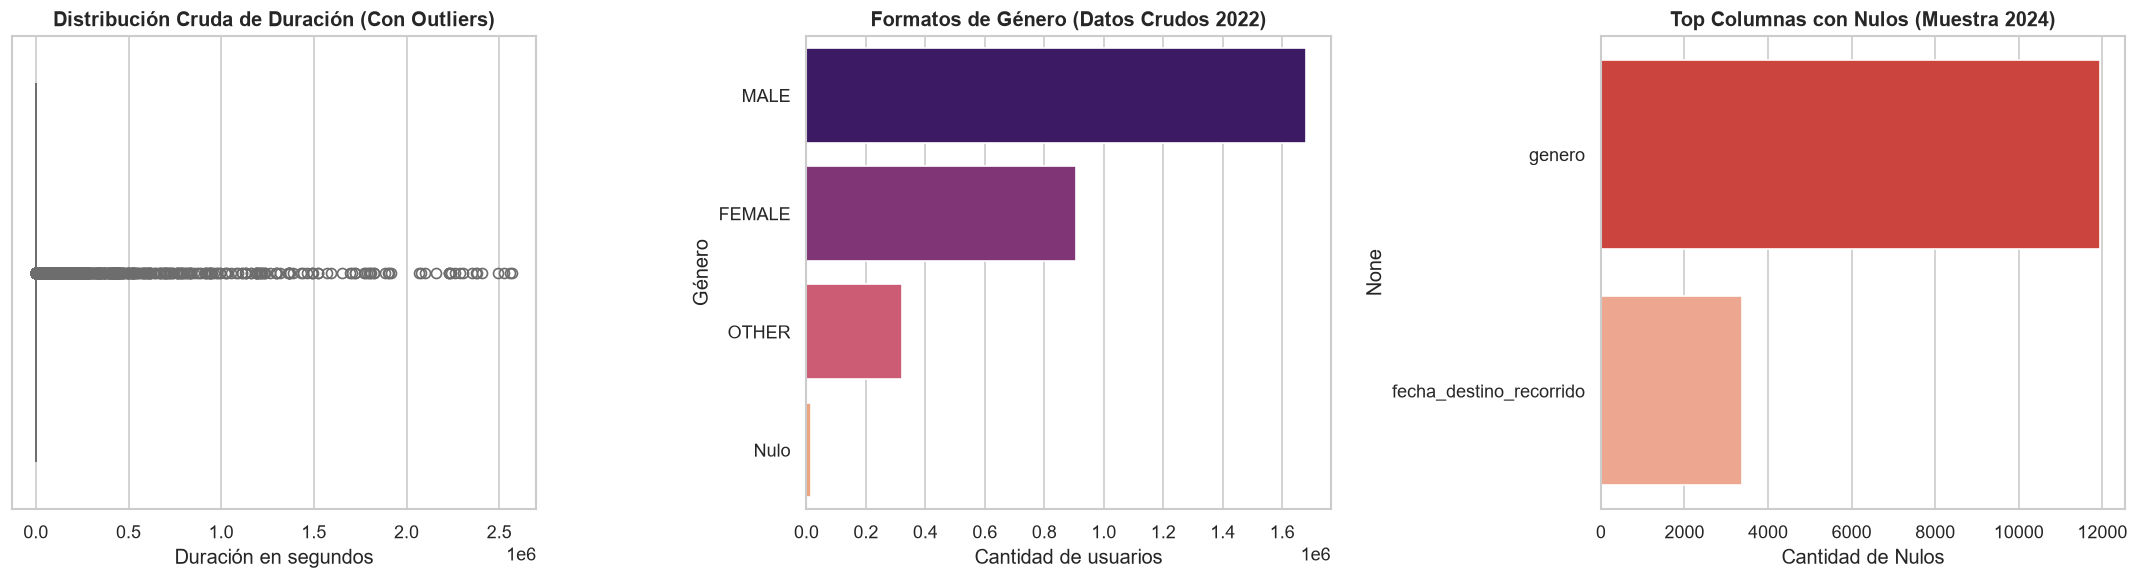

In [4]:
# ==============================================================================
# VISUALIZACIONES ALINEADAS A HIPÓTESIS (DATOS CRUDOS)
# ==============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- VIZ 1: Comprobación H1 (Outliers en Duración) ---
sns.boxplot(x=duracion_cruda, ax=axes[0], color='salmon')
axes[0].set_title('Distribución Cruda de Duración (Con Outliers)', fontweight='bold')
axes[0].set_xlabel('Duración en segundos')

# --- VIZ 2: Comprobación H2 (Inconsistencia de Género) ---
if col_genero in r2022.columns:
    genero_counts = r2022[col_genero].fillna('Nulo').value_counts()
    sns.barplot(x=genero_counts.values, y=genero_counts.index, palette='magma', ax=axes[1])
    axes[1].set_title('Formatos de Género (Datos Crudos 2022)', fontweight='bold')
    axes[1].set_xlabel('Cantidad de usuarios')

# --- VIZ 3: Comprobación H3 (Valores Nulos) ---
nulos_2024 = r2024.isna().sum()
nulos_2024 = nulos_2024[nulos_2024 > 0].sort_values(ascending=False).head(10)
if not nulos_2024.empty:
    sns.barplot(x=nulos_2024.values, y=nulos_2024.index, palette='Reds_r', ax=axes[2])
    axes[2].set_title('Top Columnas con Nulos (Muestra 2024)', fontweight='bold')
    axes[2].set_xlabel('Cantidad de Nulos')

plt.tight_layout()
plt.savefig(BASE_DIR / 'notebooks' / 'viz_eda_crudo.png', dpi=120)
plt.show()

### Conclusiones e insights sobre datos crudos
- **Insight 1 — Distribución de la respuesta (Duración):** Al graficar la duración en crudo, observamos valores máximos irreales (millones de segundos), confirmando la hipótesis 1. Esto hace imposible calcular medias reales sin aplicar un filtro previo.
- **Insight 2 — Diferencias entre categorías (Género):** Existen diferencias de capitalización y valores en blanco. Esto sugiere que el efecto analítico dependerá de estandarizar previamente estas etiquetas a "MALE", "FEMALE" y "OTHER".
- **Insight 3 — Calidad Estructural:** Se detectan columnas con nulos y nombres de variables inconsistentes entre años.
- **Observación adicional:** Estas visualizaciones demuestran que es mandatorio aplicar un Pipeline de Limpieza estructurado (Capa STG) antes de poder realizar cruces demográficos o mapas de calor funcionales.

## 3. Pipeline de Limpieza con scikit-learn

Se definen transformaciones encadenadas en un `sklearn.Pipeline`, priorizando las reglas del informe de calidad para la capa STG/Silver:

| # | Nombre | Descripcion | Justificacion |
|---|---|---|---|
| T1 | `drop_extra_cols` | Eliminar columnas indice vacias | Artefactos del CSV de 2022/2023 |
| T2 | `normalize_colnames` | Estandarizar nombres a snake_case | Consistencia entre anos |
| T3 | `clean_ids` | Quitar sufijo `BAEcobici` de IDs | Normalizar claves |
| T4 | `parse_duration` | Convertir `duracion_recorrido` a numerico con `errors="coerce"` | Tipado STG requerido |
| T5 | `parse_datetimes` | Convertir fechas a `datetime64` con `errors="coerce"` | Validaciones temporales y features |
| T6 | `parse_numerics` | Convertir edad, IDs y coordenadas a numerico | Validaciones y calculos posteriores |
| T7 | `fill_missing_categoricals` | Imputar nulos de `genero_usuario`/`modelo_bicicleta` como `unknown` | Completitud de campos categoricos |
| T8 | `normalize_gender` | Estandarizar genero a `MALE`/`FEMALE`/`OTHER` | Unificar variantes detectadas |
| T9 | `validate_recorridos` / `validate_usuarios` | Aplicar reglas de duracion, edad, fechas y coordenadas | Validez 100% en STG |

In [5]:
UNKNOWN_LABEL = "unknown"
VALID_GENDERS = {"MALE", "FEMALE", "OTHER"}

GENDER_MAP = {
    "M": "MALE", "MALE": "MALE", "MASCULINO": "MALE", "MASC": "MALE",
    "HOMBRE": "MALE", "VARON": "MALE",
    "F": "FEMALE", "FEMALE": "FEMALE", "FEMENINO": "FEMALE", "FEM": "FEMALE",
    "MUJER": "FEMALE",
    "O": "OTHER", "OTHER": "OTHER", "OTRO": "OTHER", "OTRA": "OTHER", "X": "OTHER",
    "NO BINARIO": "OTHER", "NO-BINARIO": "OTHER", "NOBINARIO": "OTHER", "NB": "OTHER",
    "PREFIERO NO DECIR": "OTHER", "SIN DATO": "OTHER", "DESCONOCIDO": "OTHER",
    "UNKNOWN": "OTHER", "NAN": "OTHER", "NONE": "OTHER", "": "OTHER",
}


def drop_extra_cols(df: pd.DataFrame) -> pd.DataFrame:
    """T1: Elimina columnas sin nombre o de indice ('', 'X')."""
    cols_to_drop = [c for c in df.columns if str(c).strip() in ('', 'X', 'Unnamed: 0')]
    return df.drop(columns=cols_to_drop, errors='ignore')


def normalize_colnames(df: pd.DataFrame) -> pd.DataFrame:
    """T2: Unifica nombres de columnas entre los 3 anos."""
    rename_map = {
        'Id_recorrido': 'id_recorrido',
        'Género': 'genero',
        'género': 'genero',
        'GÃ©nero': 'genero',
        'gÃ©nero': 'genero',
        'ID_usuario': 'id_usuario',
        'Customer.Has.Dni..Yes...No.': 'tiene_dni',
    }
    return df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})


def clean_ids(df: pd.DataFrame) -> pd.DataFrame:
    """T3: Elimina el sufijo 'BAEcobici' de las columnas de ID."""
    id_cols = [c for c in df.columns if 'id_' in c.lower() or c == 'id_usuario']
    df = df.copy()
    for col in id_cols:
        if pd.api.types.is_object_dtype(df[col]) or pd.api.types.is_string_dtype(df[col]):
            df[col] = df[col].astype('string').str.replace('BAEcobici', '', regex=False).str.strip()
    return df


def parse_duration(df: pd.DataFrame) -> pd.DataFrame:
    """T4: Convierte duracion_recorrido a numerico con errors='coerce'."""
    df = df.copy()
    if 'duracion_recorrido' in df.columns:
        df['duracion_recorrido'] = (
            df['duracion_recorrido']
            .astype(str)
            .str.replace(',', '', regex=False)
            .pipe(pd.to_numeric, errors='coerce')
        )
    return df


def parse_datetimes(df: pd.DataFrame) -> pd.DataFrame:
    """T5: Parsea columnas de fecha a datetime64 con errors='coerce'."""
    df = df.copy()
    for col in ['fecha_origen_recorrido', 'fecha_destino_recorrido', 'fecha_alta']:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors='coerce')
    return df


def parse_numerics(df: pd.DataFrame) -> pd.DataFrame:
    """T6: Convierte coordenadas, IDs y edad a numerico."""
    df = df.copy()
    numeric_cols = [
        'long_estacion_origen', 'lat_estacion_origen',
        'long_estacion_destino', 'lat_estacion_destino',
        'id_estacion_origen', 'id_estacion_destino',
        'id_usuario', 'id_recorrido', 'edad_usuario',
    ]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return df


def fill_missing_categoricals(df: pd.DataFrame) -> pd.DataFrame:
    """T7: Completa nulos categoricos definidos por calidad con 'unknown'."""
    df = df.copy()
    for col in ['genero', 'genero_usuario', 'modelo_bicicleta']:
        if col in df.columns:
            value = df[col].astype('string').str.strip()
            value = value.mask(value.str.lower().isin(['', 'nan', 'none', 'null', 'na', 'n/a']))
            df[col] = value.fillna(UNKNOWN_LABEL)
    return df


def normalize_gender(df: pd.DataFrame) -> pd.DataFrame:
    """T8: Mapea variantes de genero a MALE / FEMALE / OTHER."""
    df = df.copy()
    for col in ['genero', 'genero_usuario']:
        if col in df.columns:
            normalized = df[col].astype('string').str.upper().str.strip()
            df[col] = normalized.map(GENDER_MAP).fillna('OTHER')
    return df


def normalize_bike_model(df: pd.DataFrame) -> pd.DataFrame:
    """Normaliza espacios/capitalizacion de modelo_bicicleta preservando unknown."""
    df = df.copy()
    if 'modelo_bicicleta' in df.columns:
        model = df['modelo_bicicleta'].astype('string').str.strip()
        df['modelo_bicicleta'] = model.mask(model.str.lower() == UNKNOWN_LABEL, UNKNOWN_LABEL).fillna(UNKNOWN_LABEL)
        df.loc[df['modelo_bicicleta'] != UNKNOWN_LABEL, 'modelo_bicicleta'] = (
            df.loc[df['modelo_bicicleta'] != UNKNOWN_LABEL, 'modelo_bicicleta'].str.upper()
        )
    return df


def validate_recorridos(df: pd.DataFrame) -> pd.DataFrame:
    """T9a: Aplica reglas de validez obligatorias para recorridos STG."""
    df = df.copy()
    n_antes = len(df)
    mask = pd.Series(True, index=df.index)

    if 'id_recorrido' in df.columns:
        mask &= df['id_recorrido'].notna()
    if 'id_usuario' in df.columns:
        mask &= df['id_usuario'].notna()
    if 'duracion_recorrido' in df.columns:
        mask &= df['duracion_recorrido'].notna() & (df['duracion_recorrido'] >= 0)
    if {'fecha_origen_recorrido', 'fecha_destino_recorrido'}.issubset(df.columns):
        mask &= df['fecha_origen_recorrido'].notna()
        mask &= df['fecha_destino_recorrido'].notna()
        mask &= df['fecha_destino_recorrido'] >= df['fecha_origen_recorrido']

    coordinate_rules = {
        'lat_estacion_origen': (-90, 90),
        'lat_estacion_destino': (-90, 90),
        'long_estacion_origen': (-180, 180),
        'long_estacion_destino': (-180, 180),
    }
    for col, (min_value, max_value) in coordinate_rules.items():
        if col in df.columns:
            mask &= df[col].notna() & df[col].between(min_value, max_value)

    df = df[mask].reset_index(drop=True)
    print(f"    [T9] Filas eliminadas por reglas de validez recorridos: {n_antes - len(df):,}")
    return df


def validate_usuarios(df: pd.DataFrame) -> pd.DataFrame:
    """T9b: Aplica reglas de validez obligatorias para usuarios STG."""
    df = df.copy()
    n_antes = len(df)
    mask = pd.Series(True, index=df.index)

    if 'id_usuario' in df.columns:
        mask &= df['id_usuario'].notna()
    if 'edad_usuario' in df.columns:
        mask &= df['edad_usuario'].notna() & df['edad_usuario'].between(0, 100)
    if 'genero_usuario' in df.columns:
        mask &= df['genero_usuario'].isin(VALID_GENDERS)

    df = df[mask].reset_index(drop=True)
    print(f"    [T9] Filas eliminadas por reglas de validez usuarios: {n_antes - len(df):,}")
    return df


cleaning_pipeline = Pipeline([
    ('drop_extra_cols',              FunctionTransformer(drop_extra_cols)),
    ('normalize_colnames',           FunctionTransformer(normalize_colnames)),
    ('clean_ids',                    FunctionTransformer(clean_ids)),
    ('parse_duration',               FunctionTransformer(parse_duration)),
    ('parse_datetimes',              FunctionTransformer(parse_datetimes)),
    ('parse_numerics',               FunctionTransformer(parse_numerics)),
    ('fill_missing_categoricals',     FunctionTransformer(fill_missing_categoricals)),
    ('normalize_gender',             FunctionTransformer(normalize_gender)),
    ('normalize_bike_model',          FunctionTransformer(normalize_bike_model)),
    ('validate_recorridos',          FunctionTransformer(validate_recorridos)),
])

print("Pipeline definido:", [name for name, _ in cleaning_pipeline.steps])

Pipeline definido: ['drop_extra_cols', 'normalize_colnames', 'clean_ids', 'parse_duration', 'parse_datetimes', 'parse_numerics', 'fill_missing_categoricals', 'normalize_gender', 'normalize_bike_model', 'validate_recorridos']


In [ ]:
print("Aplicando pipeline de limpieza...")
print("\n--- 2022 ---")
stg_2022 = cleaning_pipeline.fit_transform(r2022)
print(f"  Shape resultado: {stg_2022.shape}")

print("\n--- 2023 ---")
stg_2023 = cleaning_pipeline.fit_transform(r2023)
print(f"  Shape resultado: {stg_2023.shape}")

print("\n--- 2024 ---")
stg_2024 = cleaning_pipeline.fit_transform(r2024)
print(f"  Shape resultado: {stg_2024.shape}")

Aplicando pipeline de limpieza...

--- 2022 ---


In [ ]:
COLS_RECORRIDOS = [
    'id_recorrido', 'duracion_recorrido', 'fecha_origen_recorrido',
    'id_estacion_origen', 'nombre_estacion_origen', 'direccion_estacion_origen',
    'long_estacion_origen', 'lat_estacion_origen',
    'fecha_destino_recorrido',
    'id_estacion_destino', 'nombre_estacion_destino', 'direccion_estacion_destino',
    'long_estacion_destino', 'lat_estacion_destino',
    'id_usuario', 'modelo_bicicleta', 'genero', 'anio'
]


def select_common_cols(df, cols):
    return df[[c for c in cols if c in df.columns]].copy()


recorridos = pd.concat([
    select_common_cols(stg_2022, COLS_RECORRIDOS),
    select_common_cols(stg_2023, COLS_RECORRIDOS),
    select_common_cols(stg_2024, COLS_RECORRIDOS),
], ignore_index=True)

n_antes = len(recorridos)
recorridos = recorridos.drop_duplicates(subset=['id_recorrido']).reset_index(drop=True)
print(f"Recorridos totales: {len(recorridos):,}  (eliminados {n_antes - len(recorridos):,} duplicados por id_recorrido)")
recorridos.head(3)

In [ ]:
usuarios_pipeline = Pipeline([
    ('normalize_colnames',       FunctionTransformer(normalize_colnames)),
    ('clean_ids',                FunctionTransformer(clean_ids)),
    ('parse_datetimes',          FunctionTransformer(parse_datetimes)),
    ('parse_numerics',           FunctionTransformer(parse_numerics)),
    ('fill_missing_categoricals', FunctionTransformer(fill_missing_categoricals)),
    ('normalize_gender',         FunctionTransformer(normalize_gender)),
    ('validate_usuarios',        FunctionTransformer(validate_usuarios)),
])

u_stg = pd.concat([
    usuarios_pipeline.fit_transform(u2022),
    usuarios_pipeline.fit_transform(u2023),
    usuarios_pipeline.fit_transform(u2024),
], ignore_index=True)

COLS_USUARIOS = ['id_usuario', 'genero_usuario', 'edad_usuario', 'fecha_alta', 'anio']
u_stg = u_stg[[c for c in COLS_USUARIOS if c in u_stg.columns]].copy()
n_antes = len(u_stg)
u_stg = u_stg.drop_duplicates(subset=['id_usuario']).reset_index(drop=True)
print(f"Usuarios totales STG: {len(u_stg):,}  (eliminados {n_antes - len(u_stg):,} duplicados por id_usuario)")
u_stg.head(3)

## 4. Análisis Estadístico Descriptivo y Detección de Valores Atípicos
Resumir características principales utilizando herramientas estadísticas (tendencia central, dispersión) para preparar los datos para su visualización.

In [ ]:
# --- Cálculos Base ---
rec = recorridos.copy()
rec['hora']         = rec['fecha_origen_recorrido'].dt.hour
rec['dia_semana']   = rec['fecha_origen_recorrido'].dt.dayofweek
rec['mes']          = rec['fecha_origen_recorrido'].dt.month
rec['duracion_min'] = rec['duracion_recorrido'] / 60
rec['anio_cat']     = rec['anio'].astype(str)

# --- Cálculos de Rutas ---
rutas = rec.groupby(['nombre_estacion_origen', 'nombre_estacion_destino']).size().reset_index(name='cantidad')
rutas = rutas.sort_values('cantidad', ascending=False)
rutas['trayecto'] = rutas['nombre_estacion_origen'] + ' ➔ ' + rutas['nombre_estacion_destino']

rec['es_circular'] = rec['id_estacion_origen'] == rec['id_estacion_destino']
duracion_circular = rec.groupby('es_circular')['duracion_min'].mean().reset_index()
duracion_circular['Tipo de Viaje'] = duracion_circular['es_circular'].map({True: 'Circular', False: 'Transporte'})

# --- Cálculos Demográficos ---
rec_usr = rec.merge(u_stg[['id_usuario', 'edad_usuario', 'genero_usuario']], on='id_usuario', how='inner')
bins = [0, 18, 25, 35, 50, 100]
labels = ['<18', '19-25', '26-35', '36-50', '50+']
rec_usr['rango_edad'] = pd.cut(rec_usr['edad_usuario'], bins=bins, labels=labels)

viajes_por_usuario = rec_usr.groupby('id_usuario').size()
top_20_pct_users = int(len(viajes_por_usuario) * 0.2)
viajes_ordenados = viajes_por_usuario.sort_values(ascending=False)
porcentaje_viajes_top20 = (viajes_ordenados.head(top_20_pct_users).sum() / viajes_por_usuario.sum()) * 100

# --- Impresión de Estadísticas ---
print("=== ESTADÍSTICAS GENERALES ===")
print(rec['duracion_min'].describe().round(2).to_string())

print("\n=== TOP 5 TRAYECTOS MÁS FRECUENTES ===")
# Usamos display() en lugar de print() para que renderice la tabla en HTML perfecto
display(rutas[['trayecto', 'cantidad']].head(5))

print("\n=== DURACIÓN PROMEDIO: CIRCULAR VS TRANSPORTE ===")
# Acá también aplicamos display() para mayor prolijidad
display(duracion_circular)

print("\n=== DISTRIBUCIÓN POR RANGO DE EDAD ===")
print(rec_usr['rango_edad'].value_counts().to_string())

print("\n=== LEY DE PARETO (FIDELIDAD) ===")
print(f"El 20% de los usuarios más activos realiza el {porcentaje_viajes_top20:.1f}% de todos los viajes del sistema.")

## 5. Visualización de Datos (Univariable y Bivariable)
Uso de gráficos para facilitar la interpretación de tendencias, rutas y comportamiento de usuarios.

In [ ]:
# --- VIZ 1: Evolución mensual de recorridos 2022-2024 ---
rec['mes_anio'] = rec['fecha_origen_recorrido'].dt.to_period('M')
monthly = rec.groupby(['mes_anio', 'anio_cat']).size().reset_index(name='cantidad')
monthly['mes_anio_str'] = monthly['mes_anio'].astype(str)

fig, ax = plt.subplots(figsize=(14, 5))
for anio, grp in monthly.groupby('anio_cat'):
    ax.plot(grp['mes_anio_str'], grp['cantidad'], marker='o', label=anio, linewidth=2)
ax.set_title('Evolución mensual de recorridos — Ecobici BA (2022-2024)', fontsize=13, fontweight='bold')
ax.set_xlabel('Mes')
ax.set_ylabel('Cantidad de recorridos')
ax.legend(title='Año')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(BASE_DIR / 'notebooks' / 'viz1_evolucion_mensual.png', dpi=120)
plt.show()

In [ ]:
# --- VIZ 2: Distribución horaria — hábil vs fin de semana ---
rec['es_finde'] = rec['dia_semana'].isin([5, 6])
rec['tipo_dia'] = rec['es_finde'].map({True: 'Fin de semana', False: 'Día hábil'})
hourly = rec.groupby(['hora', 'tipo_dia']).size().reset_index(name='cantidad')

dias_habiles = rec[~rec['es_finde']]['fecha_origen_recorrido'].dt.date.nunique()
dias_finde   = rec[ rec['es_finde']]['fecha_origen_recorrido'].dt.date.nunique()
hourly['por_dia'] = hourly.apply(
    lambda r: r['cantidad'] / dias_habiles if r['tipo_dia'] == 'Día hábil' else r['cantidad'] / dias_finde,
    axis=1
)

fig, ax = plt.subplots(figsize=(12, 5))
for tipo, grp in hourly.groupby('tipo_dia'):
    ax.plot(grp['hora'], grp['por_dia'], marker='o', label=tipo, linewidth=2)
ax.set_title('Recorridos por hora del día — hábil vs fin de semana (promedio diario)', fontsize=13, fontweight='bold')
ax.set_xlabel('Hora del día')
ax.set_ylabel('Recorridos promedio por día')
ax.set_xticks(range(24))
ax.legend()
plt.tight_layout()
plt.savefig(BASE_DIR / 'notebooks' / 'viz2_distribucion_horaria.png', dpi=120)
plt.show()

In [ ]:
# --- VIZ 3: Duración por modelo de bicicleta ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
data_box = rec[rec['modelo_bicicleta'].isin(['FIT', 'ICONIC'])]

data_box.boxplot(column='duracion_min', by='modelo_bicicleta',
                 ax=axes[0], showfliers=False, patch_artist=True)
axes[0].set_xlabel('Modelo de bicicleta')
axes[0].set_ylabel('Duración (minutos)')
plt.sca(axes[0])
plt.title('Boxplot (sin outliers)')

for modelo, grp in data_box.groupby('modelo_bicicleta'):
    axes[1].hist(grp['duracion_min'], bins=60, range=(0, 60),
                 alpha=0.5, label=modelo, density=True)
axes[1].set_title('Distribución de duración')
axes[1].set_xlabel('Duración (minutos)')
axes[1].set_ylabel('Densidad')
axes[1].legend()

plt.suptitle('Duración de recorridos según modelo de bicicleta', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE_DIR / 'notebooks' / 'viz3_duracion_por_modelo.png', dpi=120)
plt.show()
print("Insight 3:")
print(data_box.groupby('modelo_bicicleta')['duracion_min'].agg(['median', 'mean']).round(1).to_string())

In [ ]:
# --- VIZ 4: Top 15 estaciones de origen ---
top_est = rec['nombre_estacion_origen'].value_counts().head(15).reset_index()
top_est.columns = ['estacion', 'cantidad']

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_est['estacion'][::-1], top_est['cantidad'][::-1],
        color=sns.color_palette('Blues_r', 15))
ax.set_title('Top 15 estaciones de origen más utilizadas (2022-2024)', fontsize=13, fontweight='bold')
ax.set_xlabel('Cantidad de recorridos')
plt.tight_layout()
plt.savefig(BASE_DIR / 'notebooks' / 'viz4_top_estaciones.png', dpi=120)
plt.show()

In [ ]:
# --- VIZ 5: Top 10 Trayectos Más Frecuentes ---
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x='cantidad', y='trayecto', data=rutas.head(10), palette='viridis', ax=ax)
ax.set_title('Top 10 Trayectos Más Frecuentes (Origen ➔ Destino)', fontsize=13, fontweight='bold')
ax.set_xlabel('Cantidad de recorridos')
ax.set_ylabel('Trayecto')
plt.tight_layout()
plt.savefig(BASE_DIR / 'notebooks' / 'viz5_rutas_frecuentes.png', dpi=120)
plt.show()

In [ ]:
# --- VIZ 6: Distribución horaria según Rango de Edad ---
edad_hora = rec_usr.groupby(['rango_edad', 'hora']).size().reset_index(name='cantidad')
total_por_edad = edad_hora.groupby('rango_edad')['cantidad'].transform('sum')
edad_hora['porcentaje'] = (edad_hora['cantidad'] / total_por_edad) * 100

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=edad_hora, x='hora', y='porcentaje', hue='rango_edad', marker='o', palette='tab10', linewidth=2, ax=ax)
ax.set_title('Distribución del uso a lo largo del día según Rango de Edad', fontsize=13, fontweight='bold')
ax.set_xlabel('Hora del día')
ax.set_ylabel('Porcentaje de viajes del grupo (%)')
ax.set_xticks(range(0, 24))
plt.legend(title='Rango de Edad')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(BASE_DIR / 'notebooks' / 'viz6_edad_vs_hora.png', dpi=120)
plt.show()

In [ ]:
# --- VIZ 7: Distribución de Género por Rango de Edad ---
edad_genero = rec_usr.groupby(['rango_edad', 'genero_usuario']).size().reset_index(name='cantidad')

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=edad_genero, x='rango_edad', y='cantidad', hue='genero_usuario', palette='Set1', ax=ax)
ax.set_title('Distribución de Género según Rango de Edad', fontsize=13, fontweight='bold')
ax.set_xlabel('Rango de Edad')
ax.set_ylabel('Cantidad de Recorridos')
plt.legend(title='Género')
plt.tight_layout()
plt.savefig(BASE_DIR / 'notebooks' / 'viz7_genero_vs_edad.png', dpi=120)
plt.show()

## 6. Metricas de Calidad de Datos

Evaluacion final de la capa STG/Silver validando las reglas obligatorias del informe de calidad.

| Metrica | Objetivo | Regla aplicada |
|---|---:|---|
| Completitud | 100 % | Campos criticos sin nulos tras imputacion/filtros |
| Unicidad | 100 % | `id_recorrido` e `id_usuario` unicos |
| Validez | 100 % | Duracion `>= 0`, edad `0..100`, fechas consistentes, coordenadas validas y genero normalizado |

In [ ]:
def pct(series: pd.Series) -> float:
    return float(series.mean() * 100) if len(series) else 100.0


def print_metric(name: str, value: float) -> None:
    estado = "PASS" if np.isclose(value, 100.0) else "FAIL"
    print(f"   [{estado}] {name}: {value:.2f}%")


print("=" * 72)
print("METRICAS DE CALIDAD - CAPA STG/SILVER")
print("=" * 72)

cols_rec_criticas = [
    'id_recorrido', 'duracion_recorrido', 'fecha_origen_recorrido', 'fecha_destino_recorrido',
    'id_usuario', 'modelo_bicicleta', 'genero',
    'lat_estacion_origen', 'long_estacion_origen', 'lat_estacion_destino', 'long_estacion_destino',
]
cols_usr_criticas = ['id_usuario', 'genero_usuario', 'edad_usuario']

print("\n1. COMPLETITUD")
rec_completitud = pct(recorridos[[c for c in cols_rec_criticas if c in recorridos.columns]].notna().all(axis=1))
usr_completitud = pct(u_stg[[c for c in cols_usr_criticas if c in u_stg.columns]].notna().all(axis=1))
print_metric("Recorridos criticos completos", rec_completitud)
print_metric("Usuarios criticos completos", usr_completitud)

print("\n2. UNICIDAD")
rec_unicidad = pct(~recorridos.duplicated(subset=['id_recorrido']))
usr_unicidad = pct(~u_stg.duplicated(subset=['id_usuario']))
print_metric("id_recorrido unico", rec_unicidad)
print_metric("id_usuario unico", usr_unicidad)

print("\n3. VALIDEZ")
rec_validity_checks = []
rec_validity_checks.append(recorridos['duracion_recorrido'] >= 0)
rec_validity_checks.append(recorridos['fecha_destino_recorrido'] >= recorridos['fecha_origen_recorrido'])
rec_validity_checks.append(recorridos['lat_estacion_origen'].between(-90, 90))
rec_validity_checks.append(recorridos['lat_estacion_destino'].between(-90, 90))
rec_validity_checks.append(recorridos['long_estacion_origen'].between(-180, 180))
rec_validity_checks.append(recorridos['long_estacion_destino'].between(-180, 180))
rec_validity_checks.append(recorridos['genero'].isin(VALID_GENDERS))
rec_validity_checks.append(recorridos['modelo_bicicleta'].notna())
rec_validez = pct(pd.concat(rec_validity_checks, axis=1).all(axis=1))

usr_validity_checks = []
usr_validity_checks.append(u_stg['edad_usuario'].between(0, 100))
usr_validity_checks.append(u_stg['genero_usuario'].isin(VALID_GENDERS))
usr_validez = pct(pd.concat(usr_validity_checks, axis=1).all(axis=1))

print_metric("Recorridos validos", rec_validez)
print_metric("Usuarios validos", usr_validez)

resumen_calidad = pd.DataFrame({
    'Dataset': ['recorridos_stg', 'usuarios_stg'],
    'Completitud': [f'{rec_completitud:.2f}%', f'{usr_completitud:.2f}%'],
    'Unicidad': [f'{rec_unicidad:.2f}%', f'{usr_unicidad:.2f}%'],
    'Validez': [f'{rec_validez:.2f}%', f'{usr_validez:.2f}%'],
})

print("\nResumen:")
print(resumen_calidad.to_string(index=False))

## 7. Guardar capa STG

In [ ]:
# Nombres solicitados para STG/Silver
recorridos.to_parquet(STG_DIR / "recorridos_stg.parquet", index=False, compression='snappy')
u_stg.to_parquet(STG_DIR / "usuarios_stg.parquet", index=False, compression='snappy')

# Alias de compatibilidad: el notebook 03_MART_ML.ipynb consume estos nombres.
recorridos.to_parquet(STG_DIR / "recorridos.parquet", index=False, compression='snappy')
u_stg.to_parquet(STG_DIR / "usuarios.parquet", index=False, compression='snappy')

print("STG layer guardado:")
for f in sorted(STG_DIR.glob("*.parquet")):
    mb = f.stat().st_size / 1024**2
    df_info = pd.read_parquet(f)
    print(f"  {f.name}: {df_info.shape[0]:,} filas x {df_info.shape[1]} cols  ({mb:.0f} MB)")
print("\nSTG layer completo.")